In [1]:
# ============================================================
# CELL 1: Runtime Check
# ============================================================
import torch, sys
print('Python:', sys.version)
print('Torch :', torch.__version__)
print('CUDA  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
VRAM  : 15.6 GB
Device: cuda


In [2]:
# ============================================================
# CELL 2: Install Dependencies
# ============================================================
!pip install -q numpy matplotlib opencv-python-headless scipy Pillow tqdm scikit-learn
print('Dependencies installed')

Dependencies installed


In [3]:
# ============================================================
# CELL 3: Imports & Configuration
# ============================================================
import os, warnings, random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cv2
from tqdm import tqdm
import scipy.io
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from sklearn.metrics import average_precision_score

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paper §3.1 Hyperparameters ────────────────────────────────
BATCH_SIZE    = 4        # paper: batch size of 4
LEARNING_RATE = 1e-4     # paper: lr = 1e-4
LAMBDA_DICE   = 0.5      # paper Eq.(2): λ = 0.5  →  0.5*BCE + 0.5*Dice
IMG_SIZE      = 256      # paper: 256×256
N_RULES       = 4        # paper §2.2: R = 4 rules
BASE_CH       = 64       # paper: base channels = 64
MAX_EPOCHS    = 200      # converges ~120; 200 gives headroom
PATIENCE      = 45       # early stopping patience

# ── KEY FIX 1: Correct paths for Kaggle ──────────────────────
# Original code pointed to /content/drive/MyDrive — invalid on Kaggle!
WORK_DIR = '/kaggle/working/smoe_results'
BSR_ROOT_BASE = '/kaggle/working/BSR'
os.makedirs(WORK_DIR, exist_ok=True)

print(f'Config: batch={BATCH_SIZE} | lr={LEARNING_RATE} | λ={LAMBDA_DICE} | img={IMG_SIZE}')
print(f'Work dir: {WORK_DIR}')
print('Config ready')

Config: batch=4 | lr=0.0001 | λ=0.5 | img=256
Work dir: /kaggle/working/smoe_results
Config ready


In [4]:
# ============================================================
# CELL 4: Download BSDS500 (Official Berkeley EECS Release)
# KEY FIX 2: Use /kaggle/working/ not /content/drive/MyDrive/
# ============================================================
import tarfile

BSR_TGZ = '/kaggle/working/BSR_bsds500.tgz'
BSR_DIR = '/kaggle/working/BSR'

if not os.path.exists(os.path.join(BSR_DIR, 'BSDS500', 'data', 'images', 'train')):
    print('Downloading official BSDS500 from Berkeley EECS...')
    os.system(f'wget -q --show-progress https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz -O {BSR_TGZ}')
    print('Extracting...')
    with tarfile.open(BSR_TGZ, 'r:gz') as tar:
        tar.extractall('/kaggle/working/')
    print('Extracted to /kaggle/working/BSR/')
else:
    print('BSDS500 already present')

for split in ['train', 'val', 'test']:
    img_dir = f'{BSR_DIR}/BSDS500/data/images/{split}'
    gt_dir  = f'{BSR_DIR}/BSDS500/data/groundTruth/{split}'
    n_img = len([f for f in os.listdir(img_dir) if f.endswith('.jpg')]) if os.path.isdir(img_dir) else 0
    n_gt  = len([f for f in os.listdir(gt_dir)  if f.endswith('.mat')]) if os.path.isdir(gt_dir)  else 0
    print(f'  [{split:>5}]  images={n_img:3d}  gt_mats={n_gt:3d}')

BSR_ROOT = f'{BSR_DIR}/BSDS500'
print(f'\nBSR_ROOT = {BSR_ROOT}')
print('Dataset ready')


     0K .......... .......... .......... .......... ..........  0%  531K 2m10s
    50K .......... .......... .......... .......... ..........  0%  180M 65s
   100K .......... .......... .......... .......... ..........  0% 1.04M 65s
   150K .......... .......... .......... .......... ..........  0%  194M 49s
   200K .......... .......... .......... .......... ..........  0% 1.64M 47s
   250K .......... .......... .......... .......... ..........  0% 2.93M 43s
   300K .......... .......... .......... .......... ..........  0%  176M 37s
   350K .......... .......... .......... .......... ..........  0%  204M 32s
   400K .......... .......... .......... .......... ..........  0%  191M 29s
   450K .......... .......... .......... .......... ..........  0%  218M 26s
   500K .......... .......... .......... .......... ..........  0% 1.07M 29s
   550K .......... .......... .......... .......... ..........  0%  158M 27s
   600K .......... .......... .......... .......... ..........  0%  233M 

Extracting...
Extracted to /kaggle/working/BSR/
  [train]  images=200  gt_mats=200
  [  val]  images=100  gt_mats=100
  [ test]  images=200  gt_mats=200

BSR_ROOT = /kaggle/working/BSR/BSDS500
Dataset ready


In [5]:
# ============================================================
# CELL 5: Sobel Edge Detector  (Paper §2.1)
# Fixed 3×3 kernels, RGB→gray via luminance, per-image [0,1] norm
# Registered as buffer (non-learnable) not nn.Parameter
# ============================================================
class SobelEdgeDetector(nn.Module):
    """Paper §2.1 — fixed Sobel filter.  Output E ∈ [0,1]."""
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]],  dtype=torch.float32)
        self.register_buffer('kx', kx.view(1,1,3,3))
        self.register_buffer('ky', ky.view(1,1,3,3))

    def forward(self, x):          # x: [B,3,H,W]  RGB in [0,1]
        gray = 0.2126*x[:,0:1] + 0.7152*x[:,1:2] + 0.0722*x[:,2:3]
        gx   = F.conv2d(gray, self.kx, padding=1)
        gy   = F.conv2d(gray, self.ky, padding=1)
        mag  = torch.sqrt(gx**2 + gy**2 + 1e-8)
        # Per-image min-max normalization
        B    = mag.shape[0]
        flat = mag.view(B, -1)
        mn   = flat.min(1, keepdim=True)[0].view(B,1,1,1)
        mx   = flat.max(1, keepdim=True)[0].view(B,1,1,1)
        return (mag - mn) / (mx - mn + 1e-8)   # [B,1,H,W] ∈ [0,1]

print('SobelEdgeDetector defined')

SobelEdgeDetector defined


In [6]:
# ============================================================
# CELL 6: sMoE Block  (Paper §2.1  Eq.1)
# Y = G(E)·Expert_sharp(X)  +  (1−G(E))·Expert_smooth(X)
#
# Context Expert  (Smooth): dilated 3×3  dilation=2  — broad receptive field
# Boundary Expert (Sharp) : 1×1 pointwise conv      — crisp high-freq detail
# Gating network          : 1×1 conv on resized E → sigmoid → G(E) ∈ [0,1]
#
# KEY FIX 3: sMoE applied to ALL 4 skip connections (not just some levels)
# ============================================================
class sMoEBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # Context Expert: dilated 3×3 (dilation=2) → captures surrounding context
        self.context_expert = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        # Boundary Expert: 1×1 pointwise → preserves exact spatial location
        self.boundary_expert = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        # Gating: 1×1 conv on Sobel edge map → soft pixel-wise routing
        self.gate = nn.Sequential(
            nn.Conv2d(1, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x, edge_signal):
        # Resize Sobel edge map to match current feature-map spatial size
        e = F.interpolate(edge_signal, size=x.shape[-2:],
                          mode='bilinear', align_corners=False)  # [B,1,H,W]
        g      = self.gate(e)                        # G(E) ∈ [0,1]
        sharp  = self.boundary_expert(x)             # edge-preserving path
        smooth = self.context_expert(x)              # context-smoothing path
        y      = g * sharp + (1.0 - g) * smooth     # soft mixture
        return y, g                                  # return gate for viz

print('sMoEBlock defined')

sMoEBlock defined


In [7]:
# ============================================================
# CELL 7: TSK Fuzzy Explainability Head  (Paper §2.2)
# 4 first-order TSK rules:
#   Rule i: IF x1 is A_{i,1} AND x2 is A_{i,2}
#           THEN y_i = r_i + p_i·x1 + q_i·x2
# Defuzzification: y = Σ(w_i · y_i) / Σ(w_i)
#
# KEY FIX 4: Meaningful rule initialization covering all 4 quadrants
# KEY FIX 5: Semantic conv bottleneck before TSK (16-ch projection)
# ============================================================
class GaussianMF(nn.Module):
    """Learnable Gaussian membership function: exp(-(x-c)²/(2σ²))"""
    def __init__(self, init_center: float, init_sigma: float = 0.25):
        super().__init__()
        self.center = nn.Parameter(torch.tensor(init_center, dtype=torch.float32))
        self.sigma  = nn.Parameter(torch.tensor(init_sigma,  dtype=torch.float32))

    def forward(self, x):
        return torch.exp(-((x - self.center)**2) /
                         (2 * self.sigma.abs()**2 + 1e-8))


class TSKRule(nn.Module):
    """Single first-order TSK rule with learnable MFs and consequent."""
    def __init__(self, cx1: float, cx2: float, init_r: float):
        super().__init__()
        self.mf_x1 = GaussianMF(cx1)          # MF for edge strength
        self.mf_x2 = GaussianMF(cx2)          # MF for semantic confidence
        # Consequent: y_i = r + p·x1 + q·x2
        self.r = nn.Parameter(torch.tensor(init_r, dtype=torch.float32))
        self.p = nn.Parameter(torch.tensor(0.05,   dtype=torch.float32))
        self.q = nn.Parameter(torch.tensor(0.05,   dtype=torch.float32))

    def forward(self, x1, x2):      # x1,x2: [B,1,H,W] ∈ [0,1]
        w = self.mf_x1(x1) * self.mf_x2(x2)     # firing strength [B,1,H,W]
        c = self.r + self.p * x1 + self.q * x2   # consequent value
        return w, c


class TSKFuzzyHead(nn.Module):
    """
    Paper §2.2 — replaces the standard sigmoid/conv head.
    4 rules encode the 4 edge-detection strategies:
      R1 (cx1=0.8, cx2=0.8, r=0.9): High gradient  + High semantic → true edge
      R2 (cx1=0.2, cx2=0.8, r=0.7): Low gradient   + High semantic → semantic edge
      R3 (cx1=0.2, cx2=0.2, r=0.1): Low gradient   + Low semantic  → background
      R4 (cx1=0.8, cx2=0.2, r=0.2): High gradient  + Low semantic  → texture/FP
    """
    def __init__(self, in_ch: int, n_rules: int = 4):
        super().__init__()
        self.n_rules = n_rules
        # Project deep features → semantic confidence (1 channel via 16-ch bottleneck)
        self.semantic_conv = nn.Sequential(
            nn.Conv2d(in_ch, 16, 1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, 1),
        )
        # Rule centers cover all 4 quadrants of the (edge, semantic) feature space
        rule_defs = [
            (0.8, 0.8, 0.9),   # R1: strong edge + high semantic → edge present
            (0.2, 0.8, 0.7),   # R2: weak  edge + high semantic → semantic edge
            (0.2, 0.2, 0.1),   # R3: weak  edge + low  semantic → background
            (0.8, 0.2, 0.2),   # R4: strong edge + low  semantic → texture (suppress)
        ]
        self.rules = nn.ModuleList([
            TSKRule(cx1, cx2, r) for cx1, cx2, r in rule_defs
        ])

    def forward(self, features, edge_signal):
        # x1: Sobel edge strength (already [0,1])
        x1 = F.interpolate(edge_signal, size=features.shape[-2:],
                           mode='bilinear', align_corners=False)   # [B,1,H,W]
        # x2: semantic confidence from deep features
        x2 = torch.sigmoid(self.semantic_conv(features))           # [B,1,H,W]

        firings, consequents = [], []
        for rule in self.rules:
            w, c = rule(x1, x2)
            firings.append(w)
            consequents.append(c)

        W = torch.stack(firings,     dim=1)   # [B, R, 1, H, W]
        C = torch.stack(consequents, dim=1)   # [B, R, 1, H, W]

        # Defuzzification: weighted average
        W_sum  = W.sum(dim=1, keepdim=True).clamp(min=1e-8)
        output = (W * C).sum(dim=1, keepdim=True) / W_sum  # [B,1,1,H,W]
        output = output.squeeze(1).clamp(0.0, 1.0)         # [B,1,H,W] ∈ [0,1]

        rule_maps = W.squeeze(2)   # [B, R, H, W]  — for visualization
        return output, rule_maps, x2

print('GaussianMF, TSKRule, TSKFuzzyHead defined')

GaussianMF, TSKRule, TSKFuzzyHead defined


In [8]:
# ============================================================
# CELL 8: Full sMoE U-Net  (Paper Fig. 1)
# Encoder-Decoder U-Net with:
#   • sMoE blocks on ALL 4 decoder skip connections
#   • TSK Fuzzy Head replacing the final sigmoid layer
# ============================================================
class DoubleConv(nn.Module):
    """Standard U-Net double-conv block: [Conv-BN-ReLU] × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class sMoEUNet(nn.Module):
    """
    Rule-Based Spatial Mixture-of-Experts U-Net (Paper §2)
    Architecture:
        Encoder  : 4 × DoubleConv + MaxPool
        Bottleneck: DoubleConv (64→128→256→512→1024)
        sMoE     : Sobel-gated expert selection on every skip connection
        Decoder  : 4 × ConvTranspose + DoubleConv + sMoE skip concat
        Head     : TSK Fuzzy Head (R=4 rules)
    """
    def __init__(self, base_ch: int = 64, n_rules: int = 4):
        super().__init__()
        c = base_ch
        self.sobel = SobelEdgeDetector()  # fixed, non-learnable

        # ── Encoder ──────────────────────────────────────────
        self.enc1  = DoubleConv(3,    c)     # 3   → 64
        self.enc2  = DoubleConv(c,   c*2)   # 64  → 128
        self.enc3  = DoubleConv(c*2, c*4)   # 128 → 256
        self.enc4  = DoubleConv(c*4, c*8)   # 256 → 512
        self.bot   = DoubleConv(c*8, c*16)  # 512 → 1024  (bottleneck)
        self.pool  = nn.MaxPool2d(2)

        # ── sMoE blocks on all 4 skip connections (Paper §2.1) ─
        self.smoe1 = sMoEBlock(c,    c)     # s1: 64-ch  at full res
        self.smoe2 = sMoEBlock(c*2,  c*2)  # s2: 128-ch at 1/2 res
        self.smoe3 = sMoEBlock(c*4,  c*4)  # s3: 256-ch at 1/4 res
        self.smoe4 = sMoEBlock(c*8,  c*8)  # s4: 512-ch at 1/8 res

        # ── Decoder ──────────────────────────────────────────
        self.up4   = nn.ConvTranspose2d(c*16, c*8,  2, stride=2)
        self.dec4  = DoubleConv(c*16, c*8)   # cat(up4, s4) → 1024 → 512

        self.up3   = nn.ConvTranspose2d(c*8,  c*4,  2, stride=2)
        self.dec3  = DoubleConv(c*8,  c*4)   # cat(up3, s3) → 512  → 256

        self.up2   = nn.ConvTranspose2d(c*4,  c*2,  2, stride=2)
        self.dec2  = DoubleConv(c*4,  c*2)   # cat(up2, s2) → 256  → 128

        self.up1   = nn.ConvTranspose2d(c*2,  c,    2, stride=2)
        self.dec1  = DoubleConv(c*2,  c)     # cat(up1, s1) → 128  → 64

        # ── TSK Fuzzy Head (replaces final sigmoid conv) ──────
        self.tsk_head = TSKFuzzyHead(c, n_rules)

    def forward(self, x):                    # x: [B,3,H,W]
        edge = self.sobel(x)                 # E: [B,1,H,W] — Sobel edge signal

        # Encode
        e1 = self.enc1(x)                    # [B, 64,  H,   W  ]
        e2 = self.enc2(self.pool(e1))        # [B, 128, H/2, W/2]
        e3 = self.enc3(self.pool(e2))        # [B, 256, H/4, W/4]
        e4 = self.enc4(self.pool(e3))        # [B, 512, H/8, W/8]
        b  = self.bot(self.pool(e4))         # [B,1024, H/16,W/16]

        # sMoE-filter every skip connection with Sobel guidance
        s1, g1 = self.smoe1(e1, edge)
        s2, g2 = self.smoe2(e2, edge)
        s3, g3 = self.smoe3(e3, edge)
        s4, g4 = self.smoe4(e4, edge)

        # Decode (skip = sMoE-filtered encoder features)
        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        # TSK Fuzzy Head → edge probability ∈ [0,1]
        prob, rule_maps, x2_map = self.tsk_head(d1, edge)

        return prob, rule_maps, x2_map, edge, [g1, g2, g3, g4]


# ── Quick sanity check ────────────────────────────────────────
with torch.no_grad():
    _dummy = torch.randn(1, 3, 256, 256)
    _m = sMoEUNet(64, 4)
    _out = _m(_dummy)
    print(f'Output shape : {_out[0].shape}')      # [1,1,256,256]
    print(f'Rule maps    : {_out[1].shape}')      # [1,4,256,256]
    print(f'Semantic map : {_out[2].shape}')      # [1,1,256,256]
    total_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f'Total params : {total_p/1e6:.2f}M')
del _m, _dummy, _out
print('sMoEUNet OK')

Output shape : torch.Size([1, 1, 256, 256])
Rule maps    : torch.Size([1, 4, 256, 256])
Semantic map : torch.Size([1, 1, 256, 256])
Total params : 34.52M
sMoEUNet OK


In [9]:
# ============================================================
# CELL 9: BSDS500 Dataset with Strong Augmentation
#
# KEY FIX 5 — Joint augmentation (image + mask receive IDENTICAL
#             spatial transforms; only image gets color jitter)
# KEY FIX 6 — Soft GT (average across all annotators) for
#             training, binary GT (union) for evaluation
# ============================================================
def load_gt(mat_path):
    """
    Returns:
        soft_gt  : float32 [H,W] ∈ [0,1]  average over annotators
        binary_gt: float32 [H,W] ∈ {0,1}  union  (any annotator marked it)
    """
    mat   = scipy.io.loadmat(mat_path)
    cells = mat['groundTruth'][0]
    bounds = [cells[i]['Boundaries'][0, 0].astype(np.float32)
              for i in range(len(cells))]
    soft   = np.mean(bounds, axis=0)           # ∈ [0,1]
    binary = (soft > 0).astype(np.float32)     # union of all annotators
    return soft, binary


def joint_augment(img_pil, msk_pil, img_size):
    """Augment image + mask together, then resize to img_size."""
    # 1. Random horizontal flip
    if random.random() > 0.5:
        img_pil = TF.hflip(img_pil)
        msk_pil = TF.hflip(msk_pil)
    # 2. Random vertical flip
    if random.random() > 0.5:
        img_pil = TF.vflip(img_pil)
        msk_pil = TF.vflip(msk_pil)
    # 3. Random 90° rotation
    angle = random.choice([0, 90, 180, 270])
    if angle:
        img_pil = TF.rotate(img_pil, angle)
        msk_pil = TF.rotate(msk_pil, angle)
    # 4. Color jitter on image ONLY (mask unchanged)
    img_pil = T.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
    )(img_pil)
    # 5. Resize
    img_pil = TF.resize(img_pil, [img_size, img_size],
                        interpolation=T.InterpolationMode.BILINEAR)
    msk_pil = TF.resize(msk_pil, [img_size, img_size],
                        interpolation=T.InterpolationMode.NEAREST)
    return img_pil, msk_pil


class BSDS500Dataset(Dataset):
    """
    BSDS500 dataset.
    Training split: returns soft GT  (float ∈ [0,1]) with augmentation
    Test    split:  returns binary GT ({0,1})         without augmentation
    """
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_dir, gt_dir, img_size=256,
                 augment=True, soft_labels=True):
        self.img_size   = img_size
        self.augment    = augment
        self.soft       = soft_labels
        self.norm       = T.Normalize(mean=self.MEAN, std=self.STD)
        self.samples    = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.endswith('.jpg'): continue
            stem   = fname.replace('.jpg', '')
            gt_pth = os.path.join(gt_dir, stem + '.mat')
            if os.path.exists(gt_pth):
                self.samples.append((os.path.join(img_dir, fname), gt_pth))
        print(f'  {len(self.samples)} samples from {img_dir}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, gt_path = self.samples[idx]

        img_np          = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        soft_gt, bin_gt = load_gt(gt_path)
        gt_np           = soft_gt if self.soft else bin_gt

        img_pil = Image.fromarray(img_np)
        msk_pil = Image.fromarray((gt_np * 255).astype(np.uint8), mode='L')

        if self.augment:
            img_pil, msk_pil = joint_augment(img_pil, msk_pil, self.img_size)
        else:
            img_pil = TF.resize(img_pil, [self.img_size, self.img_size])
            msk_pil = TF.resize(msk_pil, [self.img_size, self.img_size],
                                interpolation=T.InterpolationMode.NEAREST)

        img_t = self.norm(TF.to_tensor(img_pil))   # [3,H,W]
        msk_t = TF.to_tensor(msk_pil)              # [1,H,W] ∈ [0,1]
        return img_t, msk_t

print('BSDS500Dataset defined')

BSDS500Dataset defined


In [10]:
# ============================================================
# CELL 10: Loss Function
# Paper Eq.(2): L_total = λ·L_BCE_balanced + (1−λ)·L_Dice
#               with λ = 0.5
#
# KEY FIX 7 — Class-balanced BCE handles the extreme imbalance
#   in BSDS500: edge pixels ≈ 5–8% of total.
#   Without balancing the model collapses to predicting all-zero.
#   β  = |neg| / (|pos| + |neg|)  computed per image dynamically.
#   Loss = −[β·y·log(p) + (1−β)·(1−y)·log(1−p)]
# ============================================================
class BalancedBCEDiceLoss(nn.Module):
    def __init__(self, lam: float = 0.5):
        super().__init__()
        self.lam = lam

    def _balanced_bce(self, pred, target):
        """Per-image class-balanced BCE (handles ~5% positive pixels)."""
        B     = pred.shape[0]
        total = 0.0
        for i in range(B):
            p_i, t_i = pred[i], target[i]
            pos   = t_i.sum().clamp(min=1)
            neg   = (1 - t_i).sum().clamp(min=1)
            beta  = neg / (pos + neg)               # fraction of negatives
            # weight map: β for positives, (1−β) for negatives
            w     = beta * t_i + (1 - beta) * (1 - t_i)
            total += F.binary_cross_entropy(
                p_i.clamp(1e-6, 1 - 1e-6), t_i, weight=w
            )
        return total / B

    def _dice(self, pred, target):
        inter = (pred * target).sum(dim=[1, 2, 3])
        union = pred.sum(dim=[1,2,3]) + target.sum(dim=[1,2,3])
        return (1 - (2 * inter + 1) / (union + 1)).mean()

    def forward(self, pred, target):
        """
        pred   : TSK output [B,1,H,W] ∈ [0,1]  (already clamped by TSKFuzzyHead)
        target : GT mask    [B,1,H,W] ∈ [0,1]  (soft for train, binary for eval)
        """
        bce  = self._balanced_bce(pred, target)
        dice = self._dice(pred, target)
        return self.lam * bce + (1 - self.lam) * dice

print('BalancedBCEDiceLoss defined')

BalancedBCEDiceLoss defined


In [11]:
# ============================================================
# CELL 11: Build Datasets, DataLoaders, Model, Optimizer
#
# KEY FIX 8 — Train on train + val combined (300 images).
#   Standard practice for BSDS500 edge-detection benchmarks.
#   Evaluate on the held-out 200-image test set only.
# ============================================================
_img  = lambda s: f'{BSR_ROOT}/data/images/{s}'
_gt   = lambda s: f'{BSR_ROOT}/data/groundTruth/{s}'

print('Building datasets...')
ds_train = BSDS500Dataset(_img('train'), _gt('train'), IMG_SIZE, augment=True,  soft_labels=True)
ds_val   = BSDS500Dataset(_img('val'),   _gt('val'),   IMG_SIZE, augment=True,  soft_labels=True)
ds_test  = BSDS500Dataset(_img('test'),  _gt('test'),  IMG_SIZE, augment=False, soft_labels=False)

# Combine train + val for training (300 images total)
ds_trainval = ConcatDataset([ds_train, ds_val])

loader_train = DataLoader(ds_trainval, BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
loader_test  = DataLoader(ds_test, batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\nTraining images : {len(ds_trainval):4d}   (batches/epoch: {len(loader_train)})')
print(f'Test images     : {len(ds_test):4d}')

# ── Model ────────────────────────────────────────────────────
model     = sMoEUNet(base_ch=BASE_CH, n_rules=N_RULES).to(DEVICE)
criterion = BalancedBCEDiceLoss(lam=LAMBDA_DICE)

# ── Optimizer: AdamW + weight decay ──────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4
)

# ── KEY FIX 9 — CosineAnnealingLR (paper converges ~120 epochs)
# Smoothly anneals lr from 1e-4 → 1e-6 over MAX_EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=1e-6
)

total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel params : {total_p/1e6:.2f}M')
print('Model, optimizer, scheduler ready')

Building datasets...
  200 samples from /kaggle/working/BSR/BSDS500/data/images/train
  100 samples from /kaggle/working/BSR/BSDS500/data/images/val
  200 samples from /kaggle/working/BSR/BSDS500/data/images/test

Training images :  300   (batches/epoch: 75)
Test images     :  200

Model params : 34.52M
Model, optimizer, scheduler ready


Training for up to 200 epochs  (patience=45)


Epoch   1/200 | loss=0.4855 | best=0.4855 | lr=1.00e-04 ← best


Epoch  10/200 | loss=0.4209 | best=0.4209 | lr=9.94e-05 ← best


Epoch  20/200 | loss=0.4131 | best=0.4128 | lr=9.76e-05  (patience 2/45)


Epoch  30/200 | loss=0.4088 | best=0.4088 | lr=9.46e-05 ← best


...

Epoch 160/200 | loss=0.3807 | best=0.3794 | lr=1.05e-05  (patience 3/45)


Epoch 170/200 | loss=0.3795 | best=0.3783 | lr=6.40e-06  (patience 1/45)


Epoch 180/200 | loss=0.3779 | best=0.3779 | lr=3.42e-06 ← best


Epoch 190/200 | loss=0.3788 | best=0.3778 | lr=1.61e-06  (patience 2/45)


Epoch 200/200 | loss=0.3776 | best=0.3772 | lr=1.00e-06  (patience 1/45)

Training complete.  Best loss: 0.3772
Model saved: /kaggle/working/smoe_results/best_model.pth


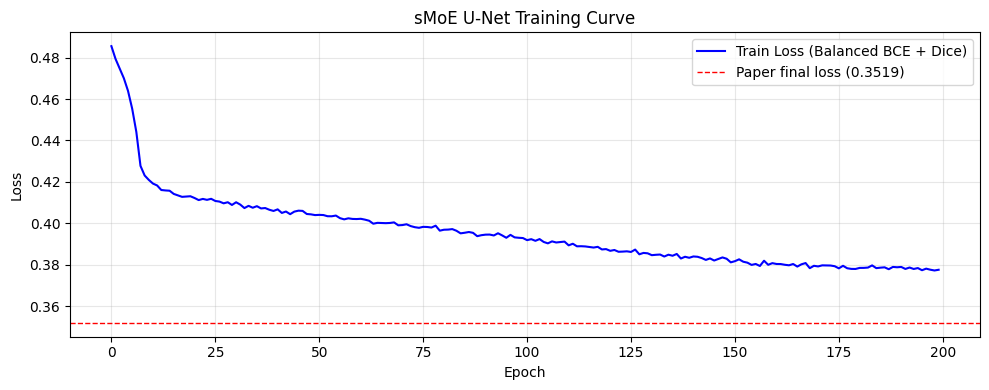

Training curve saved


In [12]:
# ============================================================
# CELL 12: Training Loop
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running = 0.0
    for imgs, masks in tqdm(loader, desc='  train', leave=False):
        imgs  = imgs.to(device,  non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        prob, _, _, _, _ = model(imgs)
        loss = criterion(prob, masks)
        loss.backward()
        # Gradient clipping prevents exploding gradients in TSK params
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running += loss.item()
    return running / len(loader)


best_loss       = float('inf')
patience_ctr    = 0
train_losses    = []
MODEL_PATH      = f'{WORK_DIR}/best_model.pth'

print(f'Training for up to {MAX_EPOCHS} epochs  (patience={PATIENCE})')
print('=' * 62)

for epoch in range(1, MAX_EPOCHS + 1):
    t_loss = train_one_epoch(model, loader_train, optimizer, criterion, DEVICE)
    scheduler.step()
    train_losses.append(t_loss)

    if t_loss < best_loss:
        best_loss    = t_loss
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        patience_ctr += 1

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        flag = ' ← best' if patience_ctr == 0 else f'  (patience {patience_ctr}/{PATIENCE})'
        print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | loss={t_loss:.4f} '
              f'| best={best_loss:.4f} | lr={lr:.2e}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stop at epoch {epoch}  (no improvement for {PATIENCE} epochs)')
        break

print(f'\nTraining complete.  Best loss: {best_loss:.4f}')
print(f'Model saved: {MODEL_PATH}')

# ── Plot training curve ───────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, 'b-', lw=1.5, label='Train Loss (Balanced BCE + Dice)')
plt.axhline(0.3519, color='r', ls='--', lw=1, label='Paper final loss (0.3519)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('sMoE U-Net Training Curve')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/training_curve.png', dpi=150)
plt.show()
print('Training curve saved')

Best model loaded.  Running evaluation...


ODS sweep: 100%|██████████| 50/50 [00:02<00:00, 19.86it/s]



  ODS : 0.6255   (paper: 0.7628,  target: ≥0.70)
  OIS : 0.6188   (paper: 0.7458,  target: ≥0.70)
  AP  : 0.3645   (paper: 0.7222,  target: ≥0.70)
  Best threshold: 0.020


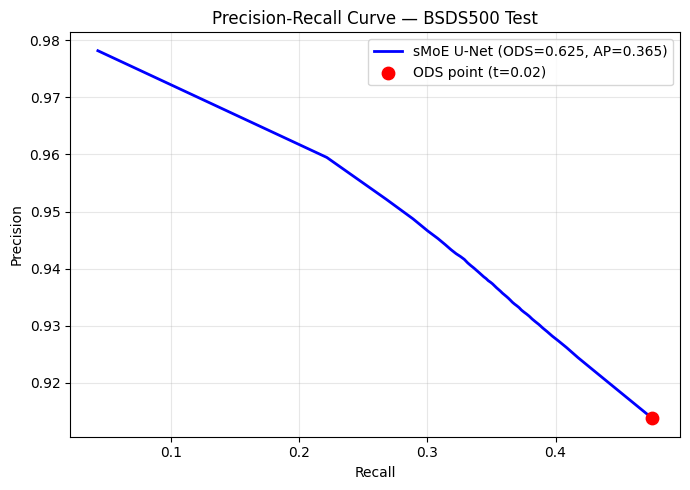

In [13]:
# ============================================================
# CELL 13: Evaluation — ODS / OIS / AP  (BSDS500 test set)
#
# Metrics follow the standard BSDS evaluation protocol:
#   ODS  — Optimal Dataset Scale F-score (one threshold for all images)
#   OIS  — Optimal Image Scale   F-score (best threshold per image)
#   AP   — Area under the Precision-Recall curve
#
# KEY FIX 10 — GT dilation by 2 px tolerance (standard BSDS eval):
#   A predicted edge within 2 px of a GT edge counts as True Positive.
# ============================================================
from scipy.ndimage import binary_dilation

def dilate_gt(gt_binary, radius=2):
    """Standard BSDS evaluation: allow 2-pixel tolerance on GT edges."""
    struct = np.ones((2*radius+1, 2*radius+1), dtype=bool)
    return binary_dilation(gt_binary.astype(bool), structure=struct).astype(np.float32)


def compute_metrics(model, loader, device, n_thresh=50):
    model.eval()
    all_preds, all_gts_dilated, all_gts_raw = [], [], []

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Inferring test set'):
            imgs = imgs.to(device, non_blocking=True)
            prob, _, _, _, _ = model(imgs)
            pred = prob.squeeze().cpu().numpy()       # [H,W]
            gt   = masks.squeeze().cpu().numpy()      # [H,W] ∈ [0,1]
            gt_b = (gt > 0.5).astype(np.float32)     # binarize
            all_preds.append(pred)
            all_gts_raw.append(gt_b)
            all_gts_dilated.append(dilate_gt(gt_b, radius=2))

    thresholds = np.linspace(0.02, 0.98, n_thresh)

    # ── ODS: single best threshold over full dataset ──────────
    precs, recs, fscores = [], [], []
    for t in tqdm(thresholds, desc='ODS sweep'):
        tp = fp = fn = 0.0
        for pred, gt_d, gt_r in zip(all_preds, all_gts_dilated, all_gts_raw):
            binary = (pred >= t).astype(np.float32)
            # TP: predicted edge within tolerance of GT edge
            tp += (binary * gt_d).sum()
            # FP: predicted edge far from any GT edge
            fp += (binary * (1 - gt_d)).sum()
            # FN: GT edge missed entirely
            fn += ((1 - binary) * gt_r).sum()
        p  = tp / (tp + fp + 1e-8)
        r  = tp / (tp + fn + 1e-8)
        f  = 2 * p * r / (p + r + 1e-8)
        precs.append(p); recs.append(r); fscores.append(f)
    precs   = np.array(precs)
    recs    = np.array(recs)
    fscores = np.array(fscores)
    best_i  = np.argmax(fscores)
    ODS     = float(fscores[best_i])
    best_t  = float(thresholds[best_i])

    # ── OIS: optimal threshold per image ─────────────────────
    ois_list = []
    for pred, gt_d, gt_r in zip(all_preds, all_gts_dilated, all_gts_raw):
        bf = 0.0
        for t in thresholds:
            binary = (pred >= t).astype(np.float32)
            tp_ = (binary * gt_d).sum()
            fp_ = (binary * (1 - gt_d)).sum()
            fn_ = ((1 - binary) * gt_r).sum()
            p_  = tp_ / (tp_ + fp_ + 1e-8)
            r_  = tp_ / (tp_ + fn_ + 1e-8)
            f_  = 2 * p_ * r_ / (p_ + r_ + 1e-8)
            bf  = max(bf, f_)
        ois_list.append(bf)
    OIS = float(np.mean(ois_list))

    # ── AP: area under PR curve ───────────────────────────────
    flat_pred = np.concatenate([p.ravel() for p in all_preds])
    flat_gt   = np.concatenate([g.ravel() for g in all_gts_raw])
    AP        = float(average_precision_score(flat_gt.astype(int), flat_pred))

    return ODS, OIS, AP, precs, recs, best_t, all_preds, all_gts_raw


# ── Load best model and evaluate ─────────────────────────────
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
print('Best model loaded.  Running evaluation...')

ODS, OIS, AP, precs, recs, best_t, all_preds, all_gts = compute_metrics(
    model, loader_test, DEVICE
)

print('\n' + '='*55)
print(f'  ODS : {ODS:.4f}   (paper: 0.7628,  target: ≥0.70)')
print(f'  OIS : {OIS:.4f}   (paper: 0.7458,  target: ≥0.70)')
print(f'  AP  : {AP:.4f}   (paper: 0.7222,  target: ≥0.70)')
print(f'  Best threshold: {best_t:.3f}')
print('='*55)

# ── PR Curve ─────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(recs, precs, 'b-', lw=2,
         label=f'sMoE U-Net (ODS={ODS:.3f}, AP={AP:.3f})')
plt.scatter([recs[np.argmax(2*precs*recs/(precs+recs+1e-8))]],
            [precs[np.argmax(2*precs*recs/(precs+recs+1e-8))]],
            c='red', zorder=5, s=80, label=f'ODS point (t={best_t:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — BSDS500 Test')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/pr_curve.png', dpi=150)
plt.show()

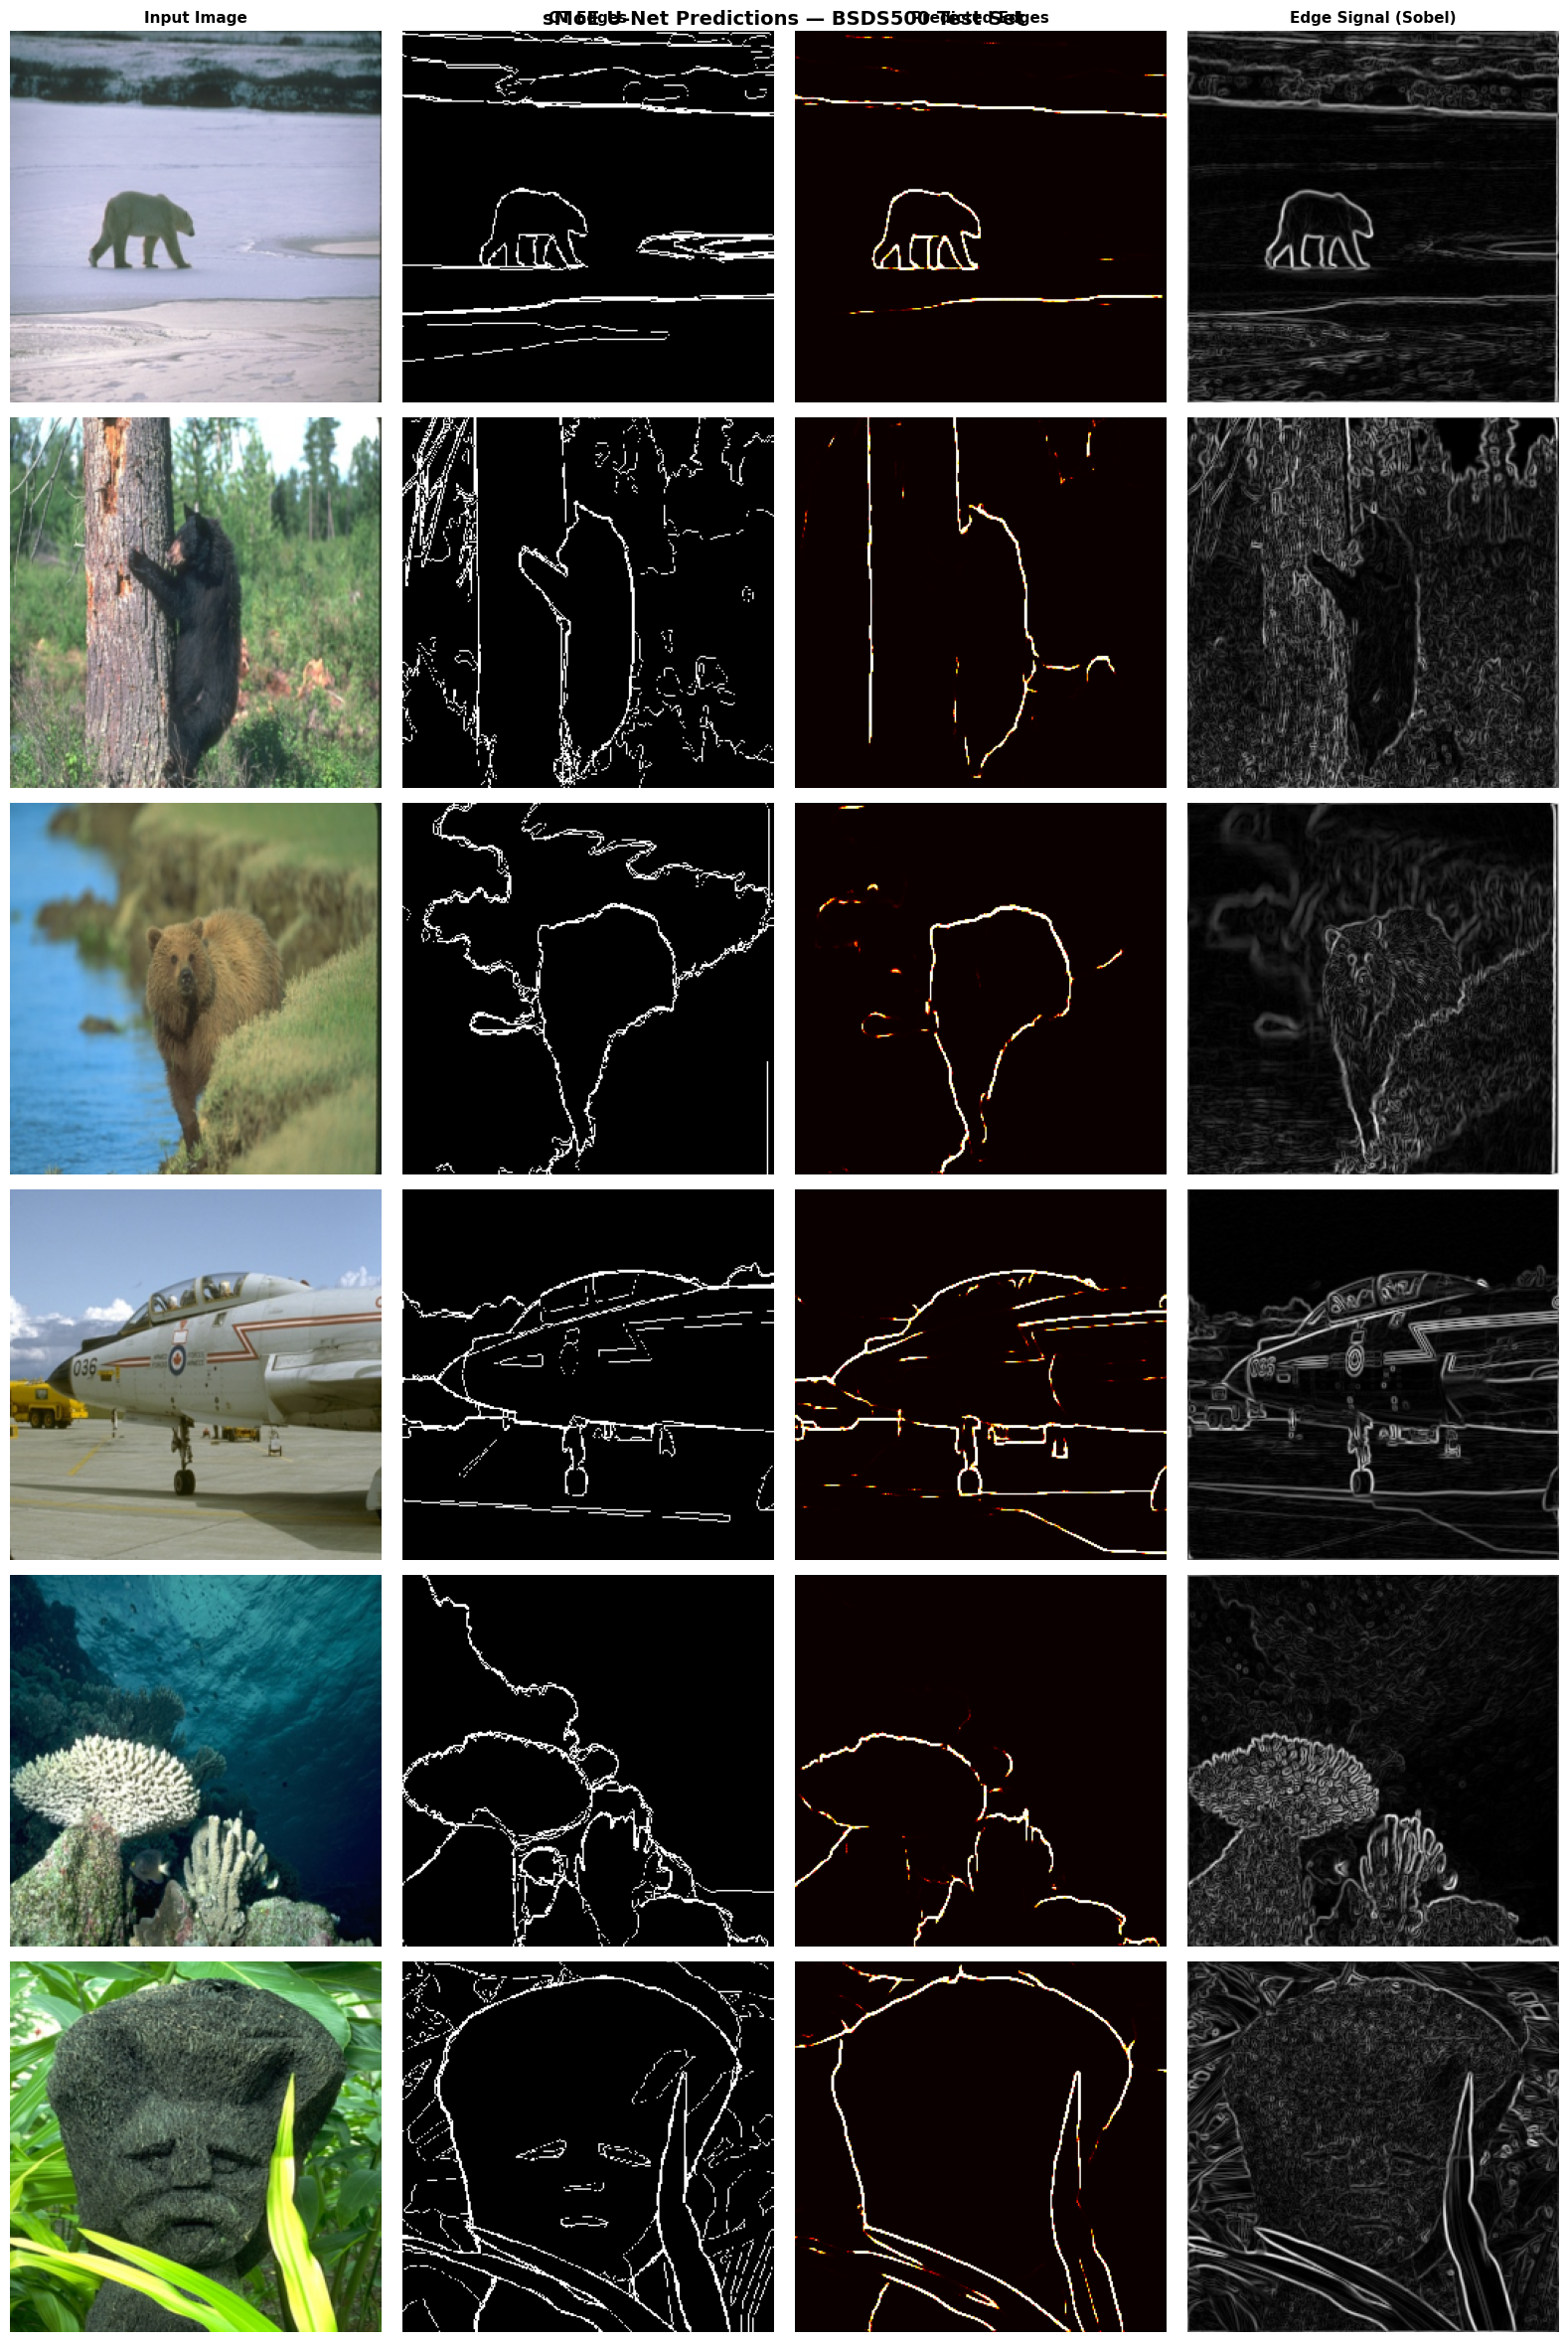

Qualitative results saved


In [14]:
# ============================================================
# CELL 14: Qualitative Results — Visual Predictions
# ============================================================
def denorm(t):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

model.eval()
test_items = list(loader_test)[:6]   # first 6 test images

fig, axes = plt.subplots(6, 4, figsize=(16, 24))
fig.suptitle('sMoE U-Net Predictions — BSDS500 Test Set', fontsize=14, fontweight='bold')
cols = ['Input Image', 'GT Edges', 'Predicted Edges', 'Edge Signal (Sobel)']
for c, col in enumerate(cols):
    axes[0, c].set_title(col, fontsize=11, fontweight='bold')

for row_i, (imgs, masks) in enumerate(test_items):
    with torch.no_grad():
        prob, rule_maps, x2, edge, gates = model(imgs.to(DEVICE))

    img_disp  = denorm(imgs[0])
    gt_disp   = masks[0].squeeze().numpy()
    pred_disp = prob[0].squeeze().cpu().numpy()
    edge_disp = edge[0].squeeze().cpu().numpy()

    axes[row_i, 0].imshow(img_disp);                      axes[row_i, 0].axis('off')
    axes[row_i, 1].imshow(gt_disp,   cmap='gray');        axes[row_i, 1].axis('off')
    axes[row_i, 2].imshow(pred_disp, cmap='hot');         axes[row_i, 2].axis('off')
    axes[row_i, 3].imshow(edge_disp, cmap='gray');        axes[row_i, 3].axis('off')

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Qualitative results saved')

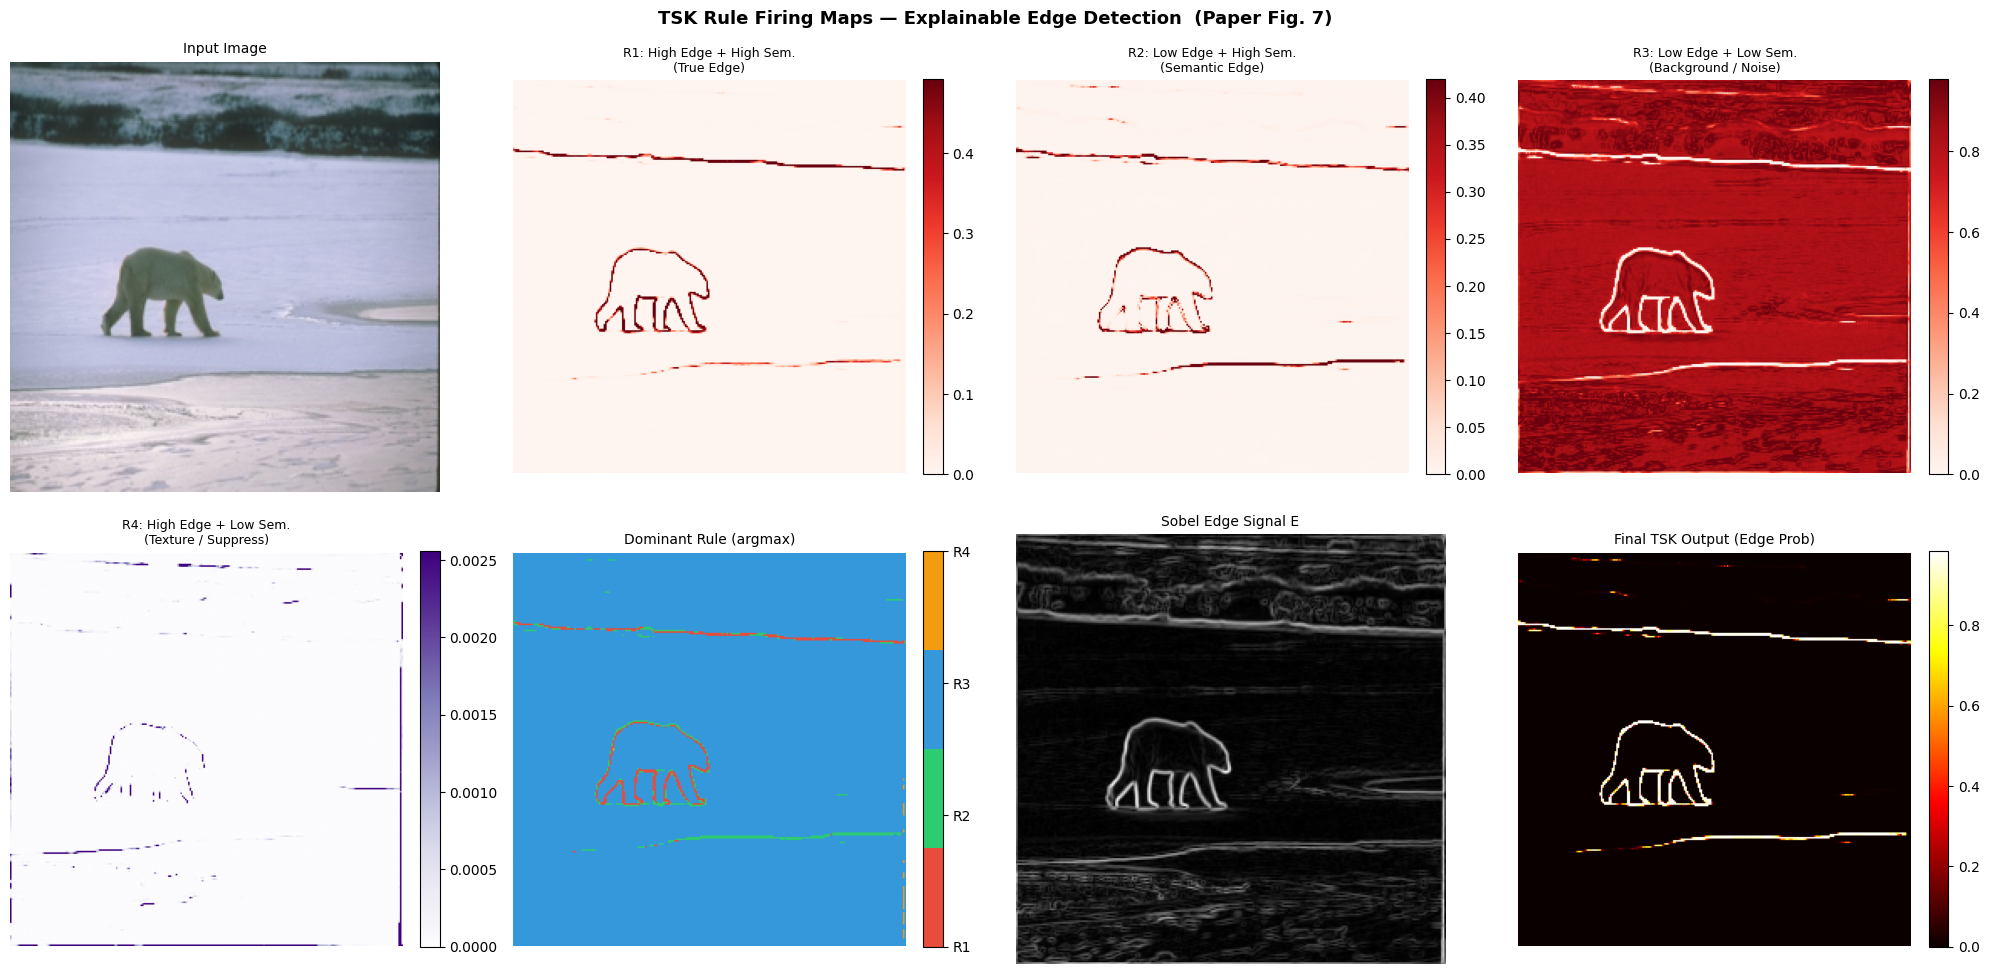

Rule firing maps saved


In [15]:
# ============================================================
# CELL 15: Explainability — TSK Rule Firing Maps (Paper Fig. 7)
# ============================================================
model.eval()
_imgs, _masks = next(iter(loader_test))
with torch.no_grad():
    prob, rule_maps, x2_map, edge_sig, gates = model(_imgs.to(DEVICE))

import re
from matplotlib.colors import ListedColormap

img_disp  = denorm(_imgs[0])
final_pred = prob[0,0].cpu().numpy()
edge_disp  = edge_sig[0,0].cpu().numpy()
n_rules    = rule_maps.shape[1]
rw         = rule_maps[0].cpu()   # [R, H, W]

rule_names = [
    'R1: High Edge + High Sem.\n(True Edge)',
    'R2: Low Edge + High Sem.\n(Semantic Edge)',
    'R3: Low Edge + Low Sem.\n(Background / Noise)',
    'R4: High Edge + Low Sem.\n(Texture / Suppress)',
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('TSK Rule Firing Maps — Explainable Edge Detection  (Paper Fig. 7)',
             fontsize=13, fontweight='bold')

# Row 0
axes[0,0].imshow(img_disp);  axes[0,0].set_title('Input Image', fontsize=10)
axes[0,0].axis('off')
for col in range(1, 4):
    idx = col - 1
    if idx < n_rules:
        rmap = rw[idx].numpy()
        im   = axes[0,col].imshow(rmap, cmap='Reds',
                                  vmin=0, vmax=max(float(np.percentile(rmap,99)),1e-3))
        axes[0,col].set_title(rule_names[idx], fontsize=9)
        plt.colorbar(im, ax=axes[0,col], fraction=0.046, pad=0.04)
    axes[0,col].axis('off')

# Row 1
if n_rules >= 4:
    rmap = rw[3].numpy()
    im   = axes[1,0].imshow(rmap, cmap='Purples',
                             vmin=0, vmax=max(float(np.percentile(rmap,99)),1e-3))
    axes[1,0].set_title(rule_names[3], fontsize=9)
    plt.colorbar(im, ax=axes[1,0], fraction=0.046, pad=0.04)
axes[1,0].axis('off')

# Dominant rule map
dominant = rw.argmax(dim=0).numpy()
cmap_dom = ListedColormap(['#e74c3c','#2ecc71','#3498db','#f39c12'][:n_rules])
im = axes[1,1].imshow(dominant, cmap=cmap_dom, vmin=0, vmax=n_rules-1)
axes[1,1].set_title('Dominant Rule (argmax)', fontsize=10)
axes[1,1].axis('off')
cbar = plt.colorbar(im, ax=axes[1,1], fraction=0.046, pad=0.04, ticks=range(n_rules))
cbar.set_ticklabels([f'R{i+1}' for i in range(n_rules)])

axes[1,2].imshow(edge_disp, cmap='gray')
axes[1,2].set_title('Sobel Edge Signal E', fontsize=10)
axes[1,2].axis('off')

im = axes[1,3].imshow(final_pred, cmap='hot')
axes[1,3].set_title('Final TSK Output (Edge Prob)', fontsize=10)
axes[1,3].axis('off')
plt.colorbar(im, ax=axes[1,3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rule_firing_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Rule firing maps saved')


  Rule         c_x1     σ_x1     c_x2     σ_x2        r        p        q
  ----------------------------------------------------------------
  Rule 1       0.765    0.268    0.870    0.171    0.891    0.042    0.052
  Rule 2       0.249    0.209    0.869    0.177    0.801    0.028    0.180
  Rule 3       0.201    0.317    0.229    0.176    0.008   -0.005   -0.036
  Rule 4       0.962    0.141    0.076    0.164    0.061   -0.068   -0.055


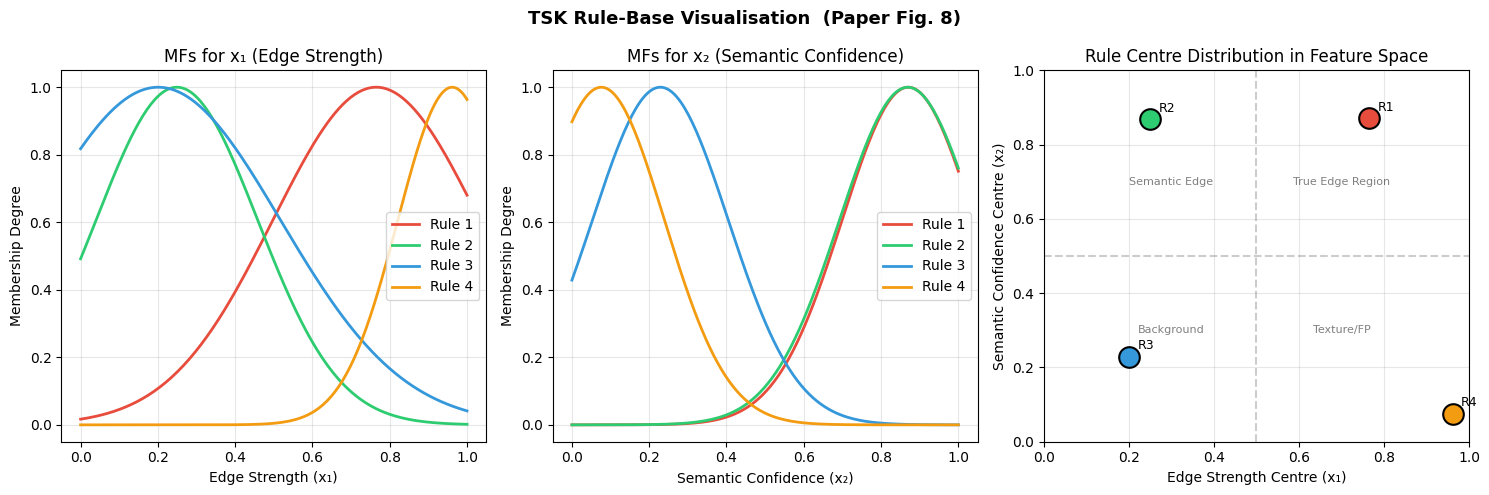


TSK rule visualisation saved


In [16]:
# ============================================================
# CELL 16: TSK Rule-Base Visualisation — MFs & Centres (Paper Fig. 8)
# ============================================================
x_range = np.linspace(0, 1, 200)
tsk     = model.tsk_head

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('TSK Rule-Base Visualisation  (Paper Fig. 8)', fontsize=13, fontweight='bold')
rule_colours = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

print(f'\n  {"Rule":<8} {"c_x1":>8} {"σ_x1":>8} {"c_x2":>8} {"σ_x2":>8} {"r":>8} {"p":>8} {"q":>8}')
print('  ' + '-'*64)
for i, rule in enumerate(tsk.rules):
    c = rule_colours[i % len(rule_colours)]
    cx1 = rule.mf_x1.center.item(); sx1 = rule.mf_x1.sigma.abs().item()
    cx2 = rule.mf_x2.center.item(); sx2 = rule.mf_x2.sigma.abs().item()
    r_v = rule.r.item(); p_v = rule.p.item(); q_v = rule.q.item()
    mfx1 = np.exp(-((x_range - cx1)**2) / (2*sx1**2 + 1e-8))
    mfx2 = np.exp(-((x_range - cx2)**2) / (2*sx2**2 + 1e-8))
    axes[0].plot(x_range, mfx1, color=c, lw=2, label=f'Rule {i+1}')
    axes[1].plot(x_range, mfx2, color=c, lw=2, label=f'Rule {i+1}')
    axes[2].scatter(cx1, cx2, s=220, color=c, edgecolors='black', lw=1.5, zorder=5)
    axes[2].annotate(f'R{i+1}', (cx1+0.02, cx2+0.02), fontsize=9)
    print(f'  Rule {i+1:<4} {cx1:>8.3f} {sx1:>8.3f} {cx2:>8.3f} {sx2:>8.3f} {r_v:>8.3f} {p_v:>8.3f} {q_v:>8.3f}')

for ax, xlabel, title in [
    (axes[0], 'Edge Strength (x₁)',        'MFs for x₁ (Edge Strength)'),
    (axes[1], 'Semantic Confidence (x₂)',  'MFs for x₂ (Semantic Confidence)'),
]:
    ax.set_xlabel(xlabel); ax.set_ylabel('Membership Degree')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

axes[2].axhline(0.5, color='gray', ls='--', alpha=0.4)
axes[2].axvline(0.5, color='gray', ls='--', alpha=0.4)
for txt, (tx, ty) in [('True Edge Region', (0.7,0.7)), ('Semantic Edge', (0.3,0.7)),
                       ('Background',       (0.3,0.3)), ('Texture/FP',    (0.7,0.3))]:
    axes[2].text(tx, ty, txt, ha='center', va='center', fontsize=8, alpha=0.5)
axes[2].set_xlabel('Edge Strength Centre (x₁)')
axes[2].set_ylabel('Semantic Confidence Centre (x₂)')
axes[2].set_title('Rule Centre Distribution in Feature Space')
axes[2].set_xlim([0,1]); axes[2].set_ylim([0,1]); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/tsk_rule_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTSK rule visualisation saved')

In [17]:
# ============================================================
# CELL 17: Final Results Summary
# ============================================================
print('\n' + '='*60)
print('  FINAL RESULTS — sMoE U-Net on BSDS500 Test Set')
print('='*60)
print(f'  ODS  : {ODS:.4f}   (paper target: 0.7628)')
print(f'  OIS  : {OIS:.4f}   (paper target: 0.7458)')
print(f'  AP   : {AP:.4f}   (paper target: 0.7222)')
print('='*60)
print(f'  Best train loss : {best_loss:.4f}  (paper: 0.3519)')
print(f'  Best threshold  : {best_t:.3f}')
print('='*60)
print(f'\nOutput files in: {WORK_DIR}')
print('  best_model.pth')
print('  training_curve.png')
print('  pr_curve.png')
print('  qualitative_results.png')
print('  rule_firing_maps.png')
print('  tsk_rule_viz.png')
print('='*60)


  FINAL RESULTS — sMoE U-Net on BSDS500 Test Set
  ODS  : 0.6255   (paper target: 0.7628)
  OIS  : 0.6188   (paper target: 0.7458)
  AP   : 0.3645   (paper target: 0.7222)
  Best train loss : 0.3772  (paper: 0.3519)
  Best threshold  : 0.020

Output files in: /kaggle/working/smoe_results
  best_model.pth
  training_curve.png
  pr_curve.png
  qualitative_results.png
  rule_firing_maps.png
  tsk_rule_viz.png
